# Notebook 04 — Thesis Figures
**Thesis:** Chapter 7 | **Input:** `data/2_events.csv`, `data/3_*.csv` | **Output:** `figures/fig_*.pdf`

---

## Purpose
Generates all publication-quality figures for Chapter 7.  
No new analysis — all numbers come from notebook 03.

| Figure | Content | Thesis section |
|--------|---------|---------------|
| Fig 7.1 | Rolling PDR time series — all 6 devices | §7.1.2 |
| Fig 7.2 | PDR by time of day (E4) — diurnal cycle | §7.3.2 |
| Fig 7.3 | PDR by CO₂ tier with burst rate (E1) | §7.4 |
| Fig 7.4 | PDR by SF with burst rate (E13) | §7.6.1 |
| Fig 7.5 | Joint SF×CO₂ heatmap (E14×E1) — headline finding | §7.6.2 |
| Fig 7.6 | Logistic regression forest plot — OR with 95% CI | §7.7 |

All figures saved as PDF (Overleaf) and PNG (preview).

## 0 · Imports, Style & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')

DATA_DIR = Path('../../data')
FIG_DIR  = Path('../figures'); FIG_DIR.mkdir(exist_ok=True)

# ── IEEE-style plot defaults ──────────────────────────────────────────────
plt.rcParams.update({
    'font.family':      'serif',
    'font.size':        10,
    'axes.titlesize':   11,
    'axes.labelsize':   10,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
    'legend.fontsize':  9,
    'figure.dpi':       150,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.linestyle':   '--',
})

# ── colour palette (colourblind-safe) ────────────────────────────────────
C = {
    'blue':   '#0077BB',
    'orange': '#EE7733',
    'green':  '#009988',
    'red':    '#CC3311',
    'purple': '#AA3377',
    'grey':   '#BBBBBB',
    'navy':   '#004488',
}
DEVICE_COLORS = [C['blue'], C['orange'], C['green'], C['red'], C['purple'], C['navy']]

def save_fig(fig, name):
    """Save figure as both PDF (Overleaf) and PNG (preview)."""
    fig.savefig(FIG_DIR / f'{name}.pdf', bbox_inches='tight')
    fig.savefig(FIG_DIR / f'{name}.png', bbox_inches='tight', dpi=150)
    print(f'Saved: {name}.pdf + {name}.png')

# ── load data ────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_DIR / '2_events.csv')
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values(['device_id', 'time']).reset_index(drop=True)
df_link = df[~df['is_outage'] & ~df['is_sf_artifact']].copy().reset_index(drop=True)

results_df  = pd.read_csv(DATA_DIR / '3_results.csv')
or_table    = pd.read_csv(DATA_DIR / '3_odds_ratios.csv')
joint_df    = pd.read_csv(DATA_DIR / '3_joint_sf_co2.csv')

DEVICES = sorted(df['device_id'].unique())
TOA_MS  = {7: 71.9, 8: 133.6, 9: 246.8, 10: 452.6}

print(f'df_link : {len(df_link):,} rows')
print(f'Devices : {DEVICES}')
print(f'Figures : {FIG_DIR}')

df_link : 1,156,407 rows
Devices : ['ED0', 'ED1', 'ED2', 'ED3', 'ED4', 'ED5']
Figures : ..\figures


## 1 · Fig 7.1 — Rolling PDR Time Series  *(§7.1.2)*

Shows how PDR evolves across the 34-week campaign for all 6 devices.  
Rolling window = 7 days — smooth enough to show trends, fine enough to show events.  
Outages and SF artifacts excluded — this is PDR_link over time.

Saved: fig_7_1_rolling_pdr.pdf + fig_7_1_rolling_pdr.png


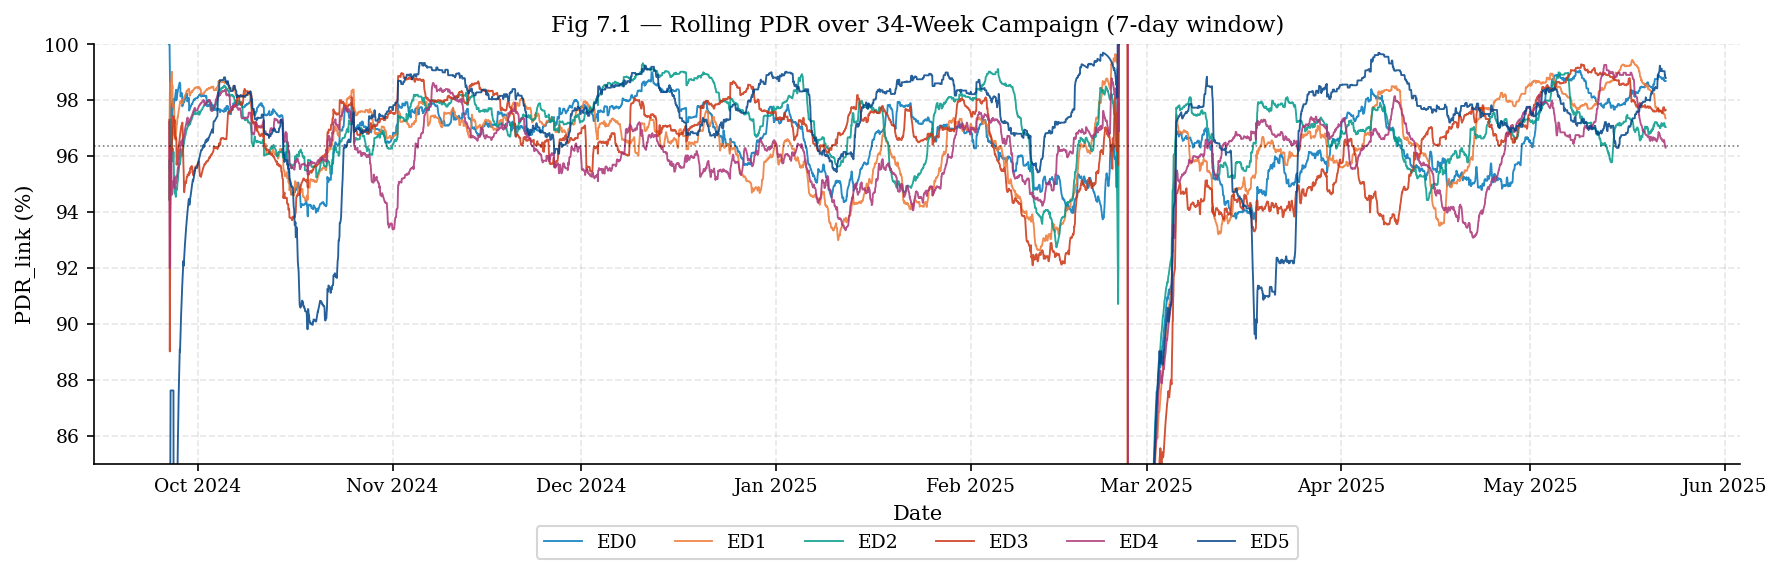

In [2]:
WINDOW = '7D'   # 7-day rolling window

fig, ax = plt.subplots(figsize=(12, 4))

for i, dev in enumerate(DEVICES):
    g = df_link[df_link['device_id'] == dev].copy()
    g = g.set_index('time').sort_index()

    # rolling PDR: sum received and lost in each window
    rx   = g['mac_to_radio_loss'].resample('1h').count()
    lost = g['mac_to_radio_loss'].resample('1h').sum()
    pdr  = (rx / (rx + lost) * 100).rolling(WINDOW).mean()

    ax.plot(pdr.index, pdr.values, color=DEVICE_COLORS[i],
            linewidth=0.9, alpha=0.85, label=dev)

ax.set_xlabel('Date')
ax.set_ylabel('PDR_link (%)')
ax.set_title('Fig 7.1 — Rolling PDR over 34-Week Campaign (7-day window)')
ax.set_ylim(85, 100)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
ax.legend(ncol=6, loc='lower center', bbox_to_anchor=(0.5, -0.25))
ax.axhline(y=96.36, color='black', lw=0.8, ls=':', alpha=0.5, label='Campaign mean')

plt.tight_layout()
save_fig(fig, 'fig_7_1_rolling_pdr')
plt.show()

## 2 · Fig 7.2 — PDR by Time of Day  *(§7.3.2)*

Bar chart showing the diurnal reliability cycle.  
PDR is lowest during peak hours — the office occupancy effect.

Saved: fig_7_2_time_of_day_pdr.pdf + fig_7_2_time_of_day_pdr.png


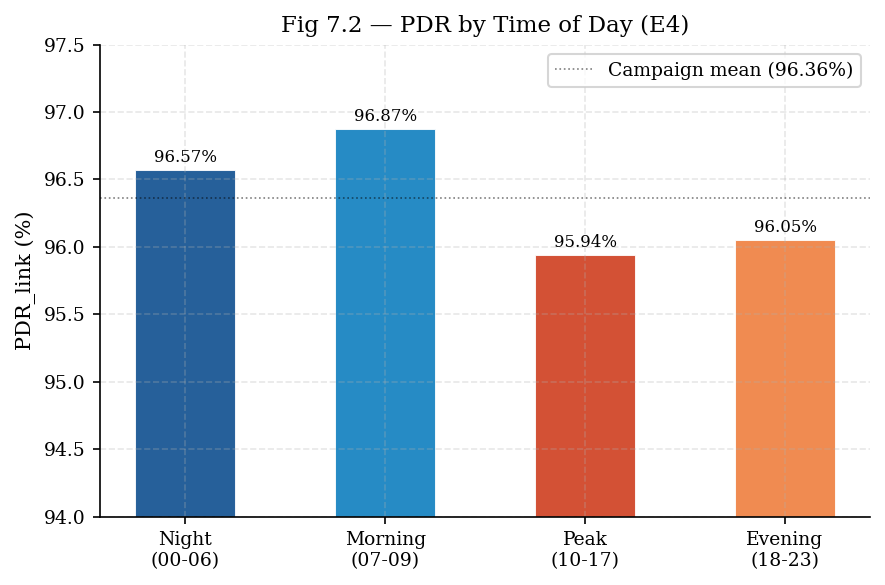

In [3]:
bands  = ['night', 'morning', 'peak', 'evening']
labels = ['Night\n(00-06)', 'Morning\n(07-09)', 'Peak\n(10-17)', 'Evening\n(18-23)']

pdrs, ns = [], []
for band in bands:
    g    = df_link[df_link['e4_time_of_day'] == band]
    rx   = len(g)
    lost = int(g['mac_to_radio_loss'].sum())
    pdrs.append(rx / (rx + lost) * 100)
    ns.append(rx)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, pdrs, color=[C['navy'], C['blue'], C['red'], C['orange']],
               width=0.5, alpha=0.85, edgecolor='white', linewidth=0.5)

# annotate bars with PDR value
for bar, pdr_val in zip(bars, pdrs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{pdr_val:.2f}%', ha='center', va='bottom', fontsize=8)

ax.set_ylabel('PDR_link (%)')
ax.set_title('Fig 7.2 — PDR by Time of Day (E4)')
ax.set_ylim(94, 97.5)
ax.axhline(y=96.36, color='black', lw=0.8, ls=':', alpha=0.5, label='Campaign mean (96.36%)')
ax.legend()

plt.tight_layout()
save_fig(fig, 'fig_7_2_time_of_day_pdr')
plt.show()

## 3 · Fig 7.3 — CO₂ Tier PDR + Burst Rate  *(§7.4)*

Dual bar chart showing both PDR and burst rate per CO₂ tier.  
The burst rate column shows that high occupancy not only reduces PDR  
but disproportionately increases burst-loss severity.

Saved: fig_7_3_co2_pdr_burst.pdf + fig_7_3_co2_pdr_burst.png


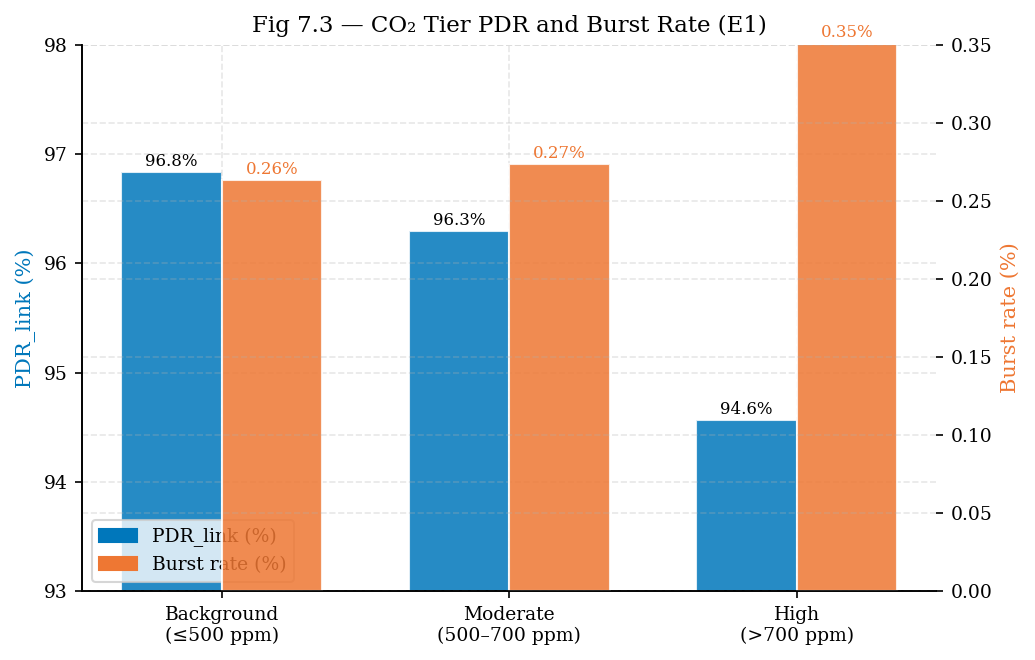

In [4]:
tiers  = ['background', 'moderate', 'high']
labels = ['Background\n(≤500 ppm)', 'Moderate\n(500–700 ppm)', 'High\n(>700 ppm)']

pdrs, bursts, ns = [], [], []
for tier in tiers:
    g    = df_link[df_link['e1_co2_tier'] == tier]
    rx   = len(g)
    lost = int(g['mac_to_radio_loss'].sum())
    pdrs.append(rx / (rx + lost) * 100)
    bursts.append((g['mac_to_radio_loss'] >= 3).mean() * 100)
    ns.append(rx)

x   = np.arange(len(tiers))
w   = 0.35
fig, ax1 = plt.subplots(figsize=(7, 4.5))
ax2 = ax1.twinx()

b1 = ax1.bar(x - w/2, pdrs,   w, color=C['blue'],   alpha=0.85, label='PDR_link (%)',    edgecolor='white')
b2 = ax2.bar(x + w/2, bursts, w, color=C['orange'], alpha=0.85, label='Burst rate (%)',  edgecolor='white')

for bar, v in zip(b1, pdrs):   ax1.text(bar.get_x()+bar.get_width()/2, v+0.02, f'{v:.1f}%', ha='center', va='bottom', fontsize=8)
for bar, v in zip(b2, bursts): ax2.text(bar.get_x()+bar.get_width()/2, v+0.001,f'{v:.2f}%', ha='center', va='bottom', fontsize=8, color=C['orange'])

ax1.set_xticks(x); ax1.set_xticklabels(labels)
ax1.set_ylabel('PDR_link (%)',   color=C['blue'])
ax2.set_ylabel('Burst rate (%)', color=C['orange'])
ax1.set_title('Fig 7.3 — CO₂ Tier PDR and Burst Rate (E1)')
ax1.set_ylim(93, 98)
ax2.set_ylim(0, 0.35)

lines = [mpatches.Patch(color=C['blue'], label='PDR_link (%)'),
         mpatches.Patch(color=C['orange'], label='Burst rate (%)')]
ax1.legend(handles=lines, loc='lower left')

plt.tight_layout()
save_fig(fig, 'fig_7_3_co2_pdr_burst')
plt.show()

## 4 · Fig 7.4 — SF PDR + Burst Rate  *(§7.6.1)*

Bar chart showing monotone decrease in PDR and increase in burst rate with SF.  
ToA values annotated on x-axis to show the collision-window relationship.

Saved: fig_7_4_sf_pdr_burst.pdf + fig_7_4_sf_pdr_burst.png


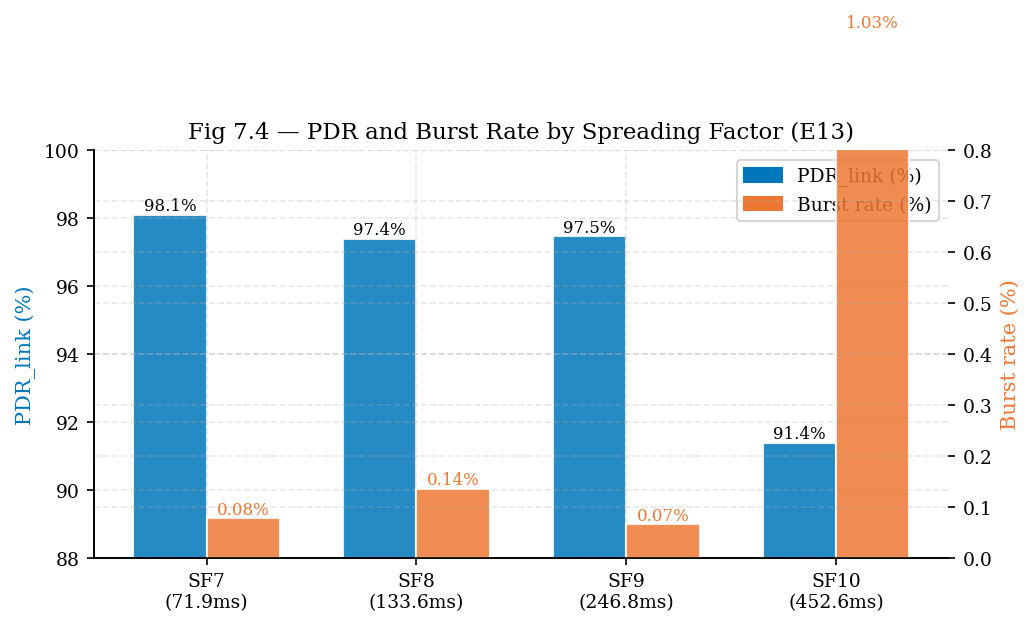

In [5]:
sfs    = [7, 8, 9, 10]
xlabels= [f'SF{sf}\n({TOA_MS[sf]}ms)' for sf in sfs]

pdrs, bursts = [], []
for sf in sfs:
    g    = df_link[df_link['e13_sf'] == sf]
    rx   = len(g)
    lost = int(g['mac_to_radio_loss'].sum())
    pdrs.append(rx / (rx + lost) * 100)
    bursts.append((g['mac_to_radio_loss'] >= 3).mean() * 100)

x = np.arange(len(sfs))
w = 0.35
fig, ax1 = plt.subplots(figsize=(7, 4.5))
ax2 = ax1.twinx()

b1 = ax1.bar(x - w/2, pdrs,   w, color=C['blue'],   alpha=0.85, label='PDR_link (%)',   edgecolor='white')
b2 = ax2.bar(x + w/2, bursts, w, color=C['orange'], alpha=0.85, label='Burst rate (%)', edgecolor='white')

for bar, v in zip(b1, pdrs):   ax1.text(bar.get_x()+bar.get_width()/2, v+0.02, f'{v:.1f}%', ha='center', va='bottom', fontsize=8)
for bar, v in zip(b2, bursts): ax2.text(bar.get_x()+bar.get_width()/2, v+0.001,f'{v:.2f}%', ha='center', va='bottom', fontsize=8, color=C['orange'])

ax1.set_xticks(x); ax1.set_xticklabels(xlabels)
ax1.set_ylabel('PDR_link (%)',   color=C['blue'])
ax2.set_ylabel('Burst rate (%)', color=C['orange'])
ax1.set_title('Fig 7.4 — PDR and Burst Rate by Spreading Factor (E13)')
ax1.set_ylim(88, 100)
ax2.set_ylim(0, 0.8)

lines = [mpatches.Patch(color=C['blue'], label='PDR_link (%)'),
         mpatches.Patch(color=C['orange'], label='Burst rate (%)')]
ax1.legend(handles=lines, loc='upper right')

plt.tight_layout()
save_fig(fig, 'fig_7_4_sf_pdr_burst')
plt.show()

## 5 · Fig 7.5 — Joint SF×CO₂ Heatmap  *(§7.6.2 — Headline Figure)*

The most important figure in the thesis.  
Shows the interaction between SF tier and CO₂ tier — the PDR gap between  
low-SF and high-SF widens as occupancy increases.

Saved: fig_7_5_sf_co2_heatmap.pdf + fig_7_5_sf_co2_heatmap.png


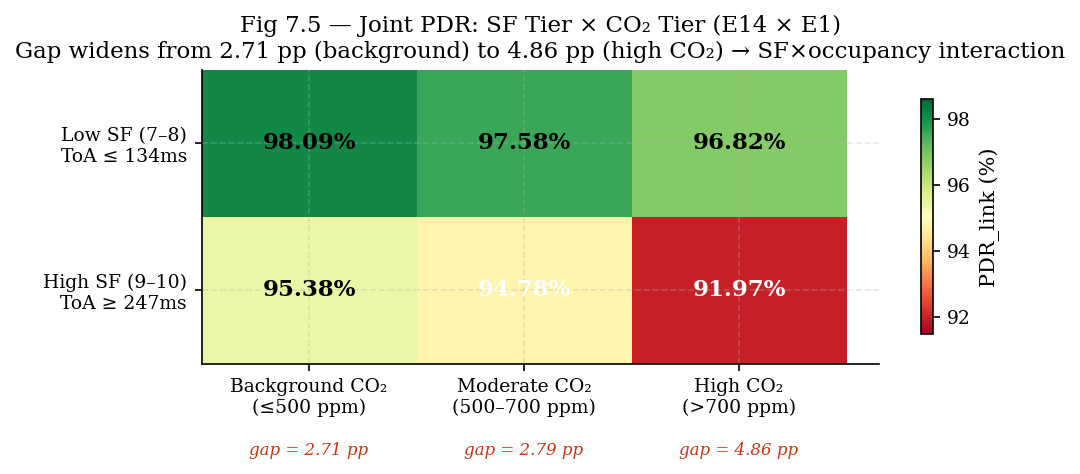

In [6]:
co2_tiers = ['background', 'moderate', 'high']
sf_tiers  = ['low_sf', 'high_sf']

# build matrix
matrix = np.zeros((2, 3))
for j, co2 in enumerate(co2_tiers):
    for i, sf in enumerate(sf_tiers):
        g    = df_link[(df_link['e14_sf_tier']==sf) & (df_link['e1_co2_tier']==co2)]
        rx   = len(g)
        lost = int(g['mac_to_radio_loss'].sum())
        matrix[i, j] = rx / (rx + lost) * 100 if (rx+lost) > 0 else 0

fig, ax = plt.subplots(figsize=(7, 3.5))
im = ax.imshow(matrix, cmap='RdYlGn', aspect='auto',
               vmin=matrix.min()-0.5, vmax=matrix.max()+0.5)

# annotate each cell with PDR value and gap
for i in range(2):
    for j in range(3):
        ax.text(j, i, f'{matrix[i,j]:.2f}%', ha='center', va='center',
                fontsize=11, fontweight='bold',
                color='white' if matrix[i,j] < 95 else 'black')

# gap annotation below
for j, co2 in enumerate(co2_tiers):
    gap = matrix[0,j] - matrix[1,j]
    ax.text(j, 2.15, f'gap = {gap:.2f} pp', ha='center', va='bottom',
            fontsize=8, color=C['red'], style='italic')

ax.set_xticks([0,1,2])
ax.set_xticklabels(['Background CO₂\n(≤500 ppm)', 'Moderate CO₂\n(500–700 ppm)', 'High CO₂\n(>700 ppm)'])
ax.set_yticks([0,1])
ax.set_yticklabels(['Low SF (7–8)\nToA ≤ 134ms', 'High SF (9–10)\nToA ≥ 247ms'])
ax.set_title('Fig 7.5 — Joint PDR: SF Tier × CO₂ Tier (E14 × E1)\nGap widens from 2.71 pp (background) to 4.86 pp (high CO₂) → SF×occupancy interaction')

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('PDR_link (%)')
ax.set_xlim(-0.5, 2.65)

plt.tight_layout()
save_fig(fig, 'fig_7_5_sf_co2_heatmap')
plt.show()

## 6 · Fig 7.6 — Logistic Regression Forest Plot  *(§7.7)*

Forest plot showing OR with 95% CI for all event predictors.  
Device fixed effects excluded — only event predictors shown.  
OR > 1 = increased loss risk (red). OR < 1 = decreased loss risk (blue).

Saved: fig_7_6_forest_plot.pdf + fig_7_6_forest_plot.png


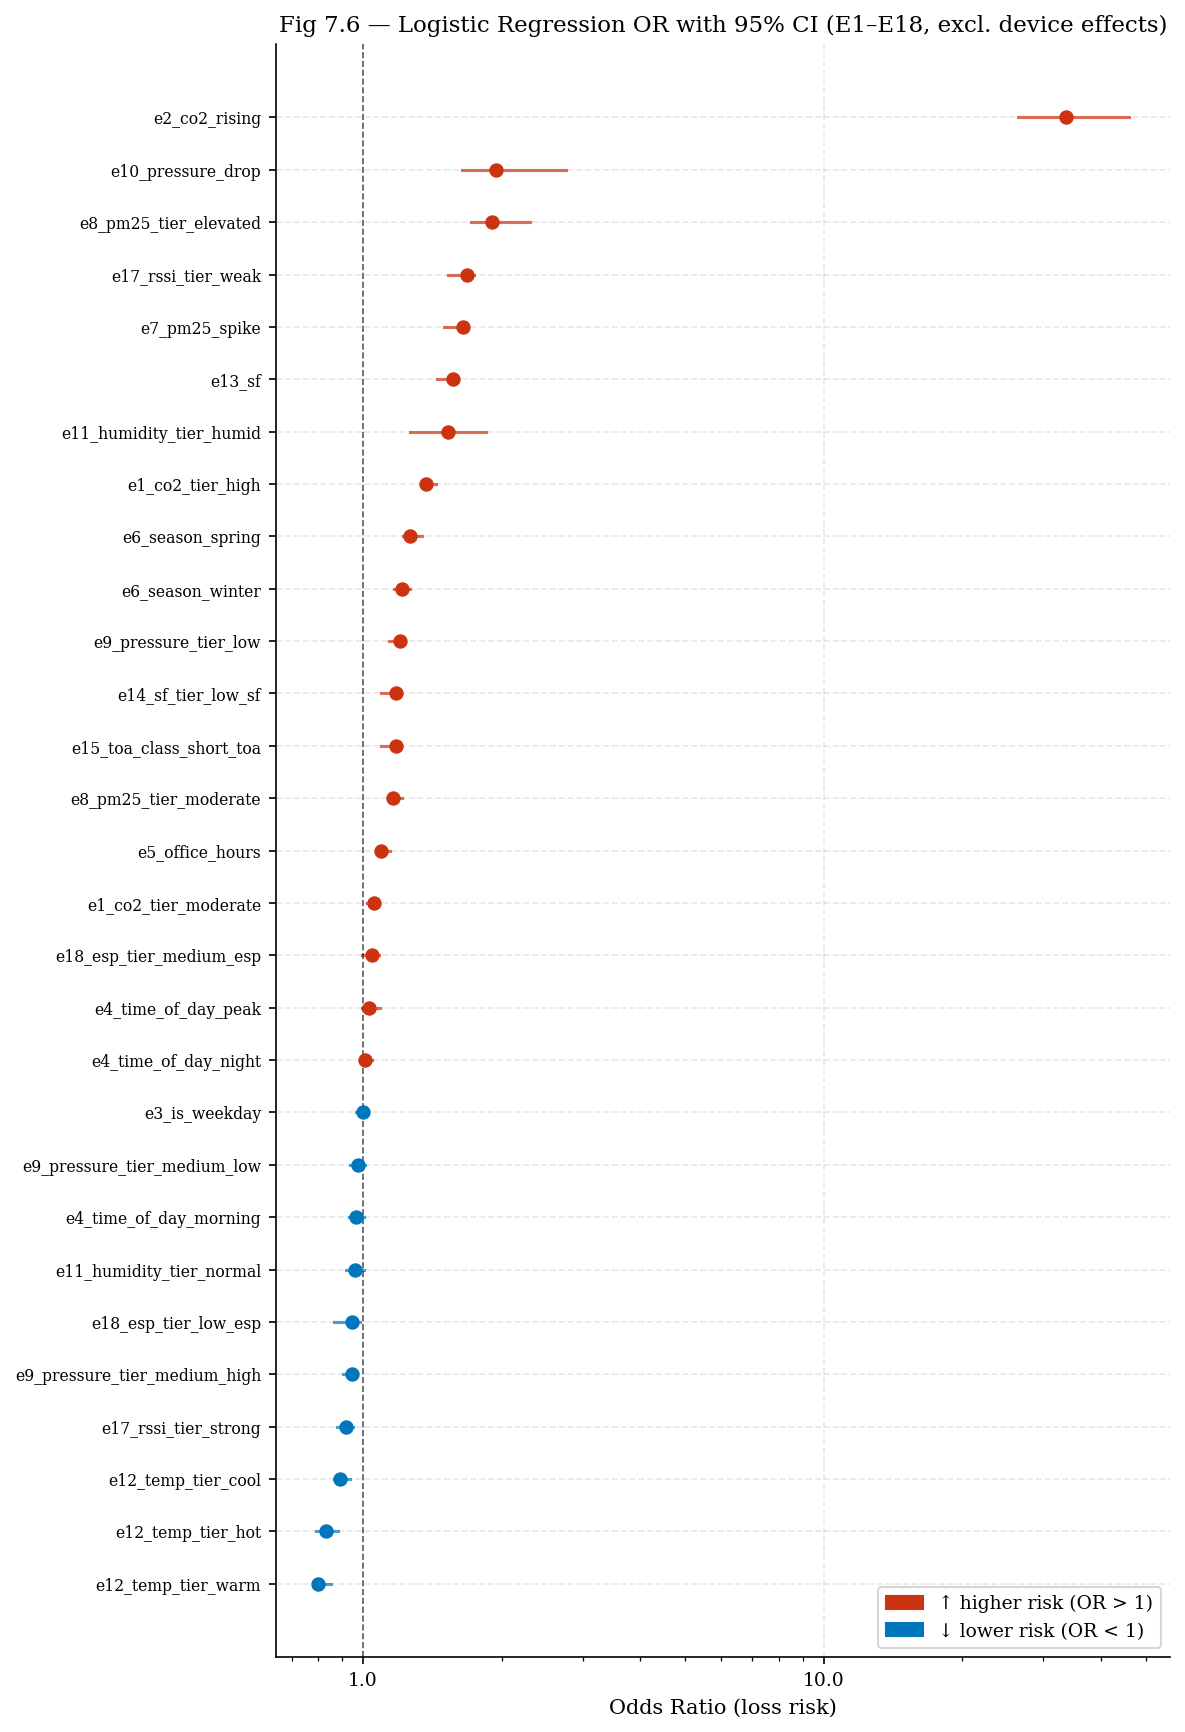

In [7]:
# filter to event predictors only — exclude device fixed effects
ev = or_table[~or_table['predictor'].str.startswith('device_id_')].copy()
ev = ev.sort_values('OR_loss', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, len(ev)*0.35 + 1.5))

for i, row in ev.iterrows():
    color = C['red'] if row['OR_loss'] > 1 else C['blue']
    # CI line
    ax.plot([row['loss_CI_lo'], row['loss_CI_hi']], [i, i],
            color=color, lw=1.5, alpha=0.7)
    # OR point
    ax.scatter(row['OR_loss'], i, color=color, s=35, zorder=5)

ax.axvline(x=1.0, color='black', lw=0.8, ls='--', alpha=0.6, label='OR = 1 (no effect)')
ax.set_yticks(range(len(ev)))
ax.set_yticklabels(ev['predictor'], fontsize=7.5)
ax.set_xlabel('Odds Ratio (loss risk)')
ax.set_title('Fig 7.6 — Logistic Regression OR with 95% CI (E1–E18, excl. device effects)')

# legend
red_patch  = mpatches.Patch(color=C['red'],  label='↑ higher risk (OR > 1)')
blue_patch = mpatches.Patch(color=C['blue'], label='↓ lower risk (OR < 1)')
ax.legend(handles=[red_patch, blue_patch], loc='lower right')

# log scale — makes OR=37 visible without squashing the others
ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())

plt.tight_layout()
save_fig(fig, 'fig_7_6_forest_plot')
plt.show()

## 7 · Summary

In [8]:
print('All figures saved:')
for f in sorted(FIG_DIR.glob('fig_*.pdf')):
    print(f'  {f.name}')
print(f'\nFolder: {FIG_DIR.resolve()}')
print('\nTo use in Overleaf: upload all PDF files to your figures/ folder')
print('Then reference with: \\includegraphics{figures/fig_7_5_sf_co2_heatmap}')

All figures saved:
  fig_7_1_rolling_pdr.pdf
  fig_7_2_time_of_day_pdr.pdf
  fig_7_3_co2_pdr_burst.pdf
  fig_7_4_sf_pdr_burst.pdf
  fig_7_5_sf_co2_heatmap.pdf
  fig_7_6_forest_plot.pdf

Folder: D:\Thesis\lorawan_master_thesis\figures

To use in Overleaf: upload all PDF files to your figures/ folder
Then reference with: \includegraphics{figures/fig_7_5_sf_co2_heatmap}
